In [ ]:
# VC Model Run

In [48]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

########################################
# Config & Setup
########################################

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

target_correlations = {1: 0.85, 2: 0.65, 3: 0.45, 4: 0.25, 5: 0.15}

########################################
# Dataset
########################################
class MelDataset(Dataset):
    def __init__(self, root):
        self.files = [os.path.join(root, f) for f in os.listdir(root) if f.endswith(".pt")]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x = torch.load(self.files[idx], weights_only=True)
        if x.shape[2] > 80:
            x = x[:, :, :80]
        else:
            pad = 80 - x.shape[2]
            x = F.pad(x, (0, pad))
        return x

# مسیر دیتاست (مطمئن شو مسیرها درست هستند)
train_dataset = MelDataset("data/librispeech_mel/train-clean-100")
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=6)

########################################
# Hierarchical Encoder
########################################
class HierarchicalEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU())
        self.conv2 = nn.Sequential(nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU())
        self.conv3 = nn.Sequential(nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU())
        self.conv4 = nn.Sequential(nn.Conv2d(128, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU())
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.projections = nn.ModuleList([nn.Linear(32, 20), nn.Linear(64, 20), nn.Linear(128, 20), 
                                          nn.Linear(128, 20), nn.Linear(128, 20), nn.Linear(128, 20)])

    def forward(self, x):
        f1 = self.conv1(x)
        f2 = self.conv2(f1)
        f3 = self.conv3(f2)
        f4 = self.conv4(f3)
        pooled = [self.pool(f1).view(x.size(0), -1), self.pool(f2).view(x.size(0), -1),
                  self.pool(f3).view(x.size(0), -1), self.pool(f4).view(x.size(0), -1),
                  self.pool(f4).view(x.size(0), -1), self.pool(f4).view(x.size(0), -1)]
        z_levels = [self.projections[i](pooled[i]) for i in range(6)]
        return torch.cat(z_levels, dim=1), z_levels

########################################
# Improved Decoder (Checkerboard-free)
########################################
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(120, 128 * 5 * 5)
        
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Upsample(scale_factor=2, mode='nearest'),
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            )

        self.deconv = nn.Sequential(
            block(128, 128),
            block(128, 64),
            block(64, 32),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 1, 3, padding=1)
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 5, 5)
        return self.deconv(x)

class HDIModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = HierarchicalEncoder()
        self.decoder = Decoder()

    def forward(self, x):
        z, levels = self.encoder(x)
        return self.decoder(z), levels

########################################
# Losses
########################################
def covariance(x):
    x = x - x.mean(dim=0, keepdim=True)
    return (x.T @ x) / (x.size(0) - 1 + 1e-6)

def correlation(x):
    cov = covariance(x)
    std = torch.sqrt(torch.diag(cov) + 1e-6)
    return cov / (std[:, None] * std[None, :] + 1e-6)

def independence_loss_v2(levels, threshold=0.2):
    z = torch.cat(levels, dim=1)
    z = z - z.mean(dim=0, keepdim=True)
    cov = (z.T @ z) / (z.shape[0] - 1 + 1e-6)
    std = torch.sqrt(torch.diag(cov) + 1e-8)
    corr = cov / (std[:, None] * std[None, :] + 1e-8)
    
    mask = torch.ones_like(corr)
    for i in range(6):
        start, end = i*20, (i+1)*20
        mask[start:end, start:end] = 0
        if i > 0: mask[(i-1)*20:i*20, start:end] = 0.5
        if i < 5: mask[(i+1)*20:(i+2)*20, start:end] = 0.5
    
    return torch.mean(torch.clamp(torch.abs(corr) - threshold, min=0) * mask)

def vertical_correlation_loss(levels):
    loss = 0
    for i in range(len(levels)):
        for j in range(i+1, len(levels)):
            distance = j - i
            target = target_correlations.get(distance, 0)
            corr = correlation(torch.cat([levels[i], levels[j]], dim=1))
            cross = corr[:levels[i].size(1), levels[i].size(1):]
            loss += F.relu(target - cross).mean()
    return loss

def orthogonality_loss(levels):
    loss = 0
    for z in levels:
        cov = covariance(z)
        loss += ((cov - torch.eye(cov.size(0), device=z.device))**2).mean()
    return loss

########################################
# Training Loop
########################################
model = HDIModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
best_loss = float("inf")

for epoch in range(100):
    model.train()
    total_rec, total_vert, total_ind, total_ortho, total_sparse = 0, 0, 0, 0, 0
    
    # Scheduling
    if epoch < 5: w_rec, w_vert, w_ind, w_ortho, w_sparse = 1.0, 0.0, 0.0, 0.0, 0.0
    elif epoch < 12: w_rec, w_vert, w_ind, w_ortho, w_sparse = 1.0, 0.5, 0.8, 0.1, 0.01
    else: w_rec, w_vert, w_ind, w_ortho, w_sparse = 1.0, 0.5, 5.0, 0.3, 0.05

    for batch in train_loader:
        batch = batch.to(device)
        recon, levels = model(batch)
        
        loss_rec = F.mse_loss(recon, batch)
        loss_vert = vertical_correlation_loss(levels)
        loss_ind = independence_loss_v2(levels)
        loss_ortho = orthogonality_loss(levels)
        loss_sparse = torch.mean(torch.abs(torch.cat(levels, dim=1)))
        
        loss = w_rec*loss_rec + w_vert*loss_vert + w_ind*loss_ind + w_ortho*loss_ortho + w_sparse*loss_sparse
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_rec += loss_rec.item()
        total_vert += loss_vert.item()
        total_ind += loss_ind.item()
        total_ortho += loss_ortho.item()
        total_sparse += loss_sparse.item()

    avg_rec = total_rec / len(train_loader)
    print(f"Epoch {epoch} | Loss: {avg_rec:.4f}")
    
    # Save best model at the END of epoch
    if avg_rec < best_loss:
        best_loss = avg_rec
        torch.save(model.state_dict(), "hdi_model_best.pt")
        print("Model saved ✅")


Using device: cpu
Epoch 0 | Loss: 0.4235
Model saved ✅
Epoch 1 | Loss: 0.3251
Model saved ✅
Epoch 2 | Loss: 0.2927
Model saved ✅
Epoch 3 | Loss: 0.2771
Model saved ✅
Epoch 4 | Loss: 0.2659
Model saved ✅
Epoch 5 | Loss: 0.3265
Epoch 6 | Loss: 0.2837
Epoch 7 | Loss: 0.2742
Epoch 8 | Loss: 0.2686
Epoch 9 | Loss: 0.2633
Model saved ✅
Epoch 10 | Loss: 0.2606
Model saved ✅
Epoch 11 | Loss: 0.2569
Model saved ✅
Epoch 12 | Loss: 0.2606
Epoch 13 | Loss: 0.2566
Model saved ✅
Epoch 14 | Loss: 0.2542
Model saved ✅
Epoch 15 | Loss: 0.2530
Model saved ✅
Epoch 16 | Loss: 0.2508
Model saved ✅
Epoch 17 | Loss: 0.2488
Model saved ✅
Epoch 18 | Loss: 0.2467
Model saved ✅
Epoch 19 | Loss: 0.2455
Model saved ✅
Epoch 20 | Loss: 0.2440
Model saved ✅
Epoch 21 | Loss: 0.2428
Model saved ✅
Epoch 22 | Loss: 0.2407
Model saved ✅
Epoch 23 | Loss: 0.2393
Model saved ✅
Epoch 24 | Loss: 0.2377
Model saved ✅
Epoch 25 | Loss: 0.2369
Model saved ✅
Epoch 26 | Loss: 0.2349
Model saved ✅
Epoch 27 | Loss: 0.2339
Model saved 

In [ ]:
##########

In [5]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

########################################
# Config & Setup
########################################

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


########################################
# Hierarchical Encoder
########################################
class HierarchicalEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU())
        self.conv2 = nn.Sequential(nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU())
        self.conv3 = nn.Sequential(nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU())
        self.conv4 = nn.Sequential(nn.Conv2d(128, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU())
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.projections = nn.ModuleList([nn.Linear(32, 20), nn.Linear(64, 20), nn.Linear(128, 20), 
                                          nn.Linear(128, 20), nn.Linear(128, 20), nn.Linear(128, 20)])

    def forward(self, x):
        f1 = self.conv1(x)
        f2 = self.conv2(f1)
        f3 = self.conv3(f2)
        f4 = self.conv4(f3)
        pooled = [self.pool(f1).view(x.size(0), -1), self.pool(f2).view(x.size(0), -1),
                  self.pool(f3).view(x.size(0), -1), self.pool(f4).view(x.size(0), -1),
                  self.pool(f4).view(x.size(0), -1), self.pool(f4).view(x.size(0), -1)]
        z_levels = [self.projections[i](pooled[i]) for i in range(6)]
        return torch.cat(z_levels, dim=1), z_levels

########################################
# Improved Decoder (Checkerboard-free)
########################################
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(120, 128 * 5 * 5)
        
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Upsample(scale_factor=2, mode='nearest'),
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            )

        self.deconv = nn.Sequential(
            block(128, 128),
            block(128, 64),
            block(64, 32),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 1, 3, padding=1)
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 5, 5)
        return self.deconv(x)

class HDIModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = HierarchicalEncoder()
        self.decoder = Decoder()

    def forward(self, x):
        z, levels = self.encoder(x)
        return self.decoder(z), levels

########################################
# Losses
########################################
def covariance(x):
    x = x - x.mean(dim=0, keepdim=True)
    return (x.T @ x) / (x.size(0) - 1 + 1e-6)

def correlation(x):
    cov = covariance(x)
    std = torch.sqrt(torch.diag(cov) + 1e-6)
    return cov / (std[:, None] * std[None, :] + 1e-6)

def independence_loss_v2(levels, threshold=0.2):
    z = torch.cat(levels, dim=1)
    z = z - z.mean(dim=0, keepdim=True)
    cov = (z.T @ z) / (z.shape[0] - 1 + 1e-6)
    std = torch.sqrt(torch.diag(cov) + 1e-8)
    corr = cov / (std[:, None] * std[None, :] + 1e-8)
    
    mask = torch.ones_like(corr)
    for i in range(6):
        start, end = i*20, (i+1)*20
        mask[start:end, start:end] = 0
        if i > 0: mask[(i-1)*20:i*20, start:end] = 0.5
        if i < 5: mask[(i+1)*20:(i+2)*20, start:end] = 0.5
    
    return torch.mean(torch.clamp(torch.abs(corr) - threshold, min=0) * mask)

def vertical_correlation_loss(levels):
    loss = 0
    for i in range(len(levels)):
        for j in range(i+1, len(levels)):
            distance = j - i
            target = target_correlations.get(distance, 0)
            corr = correlation(torch.cat([levels[i], levels[j]], dim=1))
            cross = corr[:levels[i].size(1), levels[i].size(1):]
            loss += F.relu(target - cross).mean()
    return loss

def orthogonality_loss(levels):
    loss = 0
    for z in levels:
        cov = covariance(z)
        loss += ((cov - torch.eye(cov.size(0), device=z.device))**2).mean()
    return loss

########################################
# Training Loop
########################################
model = HDIModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
best_loss = float("inf")

Using device: cuda


In [3]:
import os
import torch

def load_model_safely(model, checkpoint_path, device, strict=True):
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    # اگر نسخه torch پشتیبانی کند:
    try:
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(checkpoint_path, map_location=device)

    print(f"Loaded file: {checkpoint_path}")
    print("Top-level object type:", type(ckpt))

    if isinstance(ckpt, dict):
        print("Top-level keys:", list(ckpt.keys())[:10])

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
        print("Using ckpt['model_state_dict']")
    else:
        state_dict = ckpt
        print("Using raw state_dict")

    missing, unexpected = model.load_state_dict(state_dict, strict=strict)

    print("Model weights loaded.")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    if isinstance(ckpt, dict):
        if "epoch" in ckpt:
            print("Saved epoch:", ckpt["epoch"])
        if "loss" in ckpt:
            print("Saved loss:", ckpt["loss"])

    model.to(device)
    return model


In [4]:
checkpoint_path = "hdi_model_best_100Epoch.pt"
model = load_model_safely(model, checkpoint_path, device)
model.eval()


Loaded file: hdi_model_best_100Epoch.pt
Top-level object type: <class 'collections.OrderedDict'>
Top-level keys: ['encoder.conv1.0.weight', 'encoder.conv1.0.bias', 'encoder.conv1.1.weight', 'encoder.conv1.1.bias', 'encoder.conv1.1.running_mean', 'encoder.conv1.1.running_var', 'encoder.conv1.1.num_batches_tracked', 'encoder.conv2.0.weight', 'encoder.conv2.0.bias', 'encoder.conv2.1.weight']
Using raw state_dict
Model weights loaded.
Missing keys: []
Unexpected keys: []


HDIModel(
  (encoder): HierarchicalEncoder(
    (conv1): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (conv2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (conv3): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (conv4): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (pool): AdaptiveAvgPool2d(output_size=(1, 1))
    (projections): ModuleList(
   

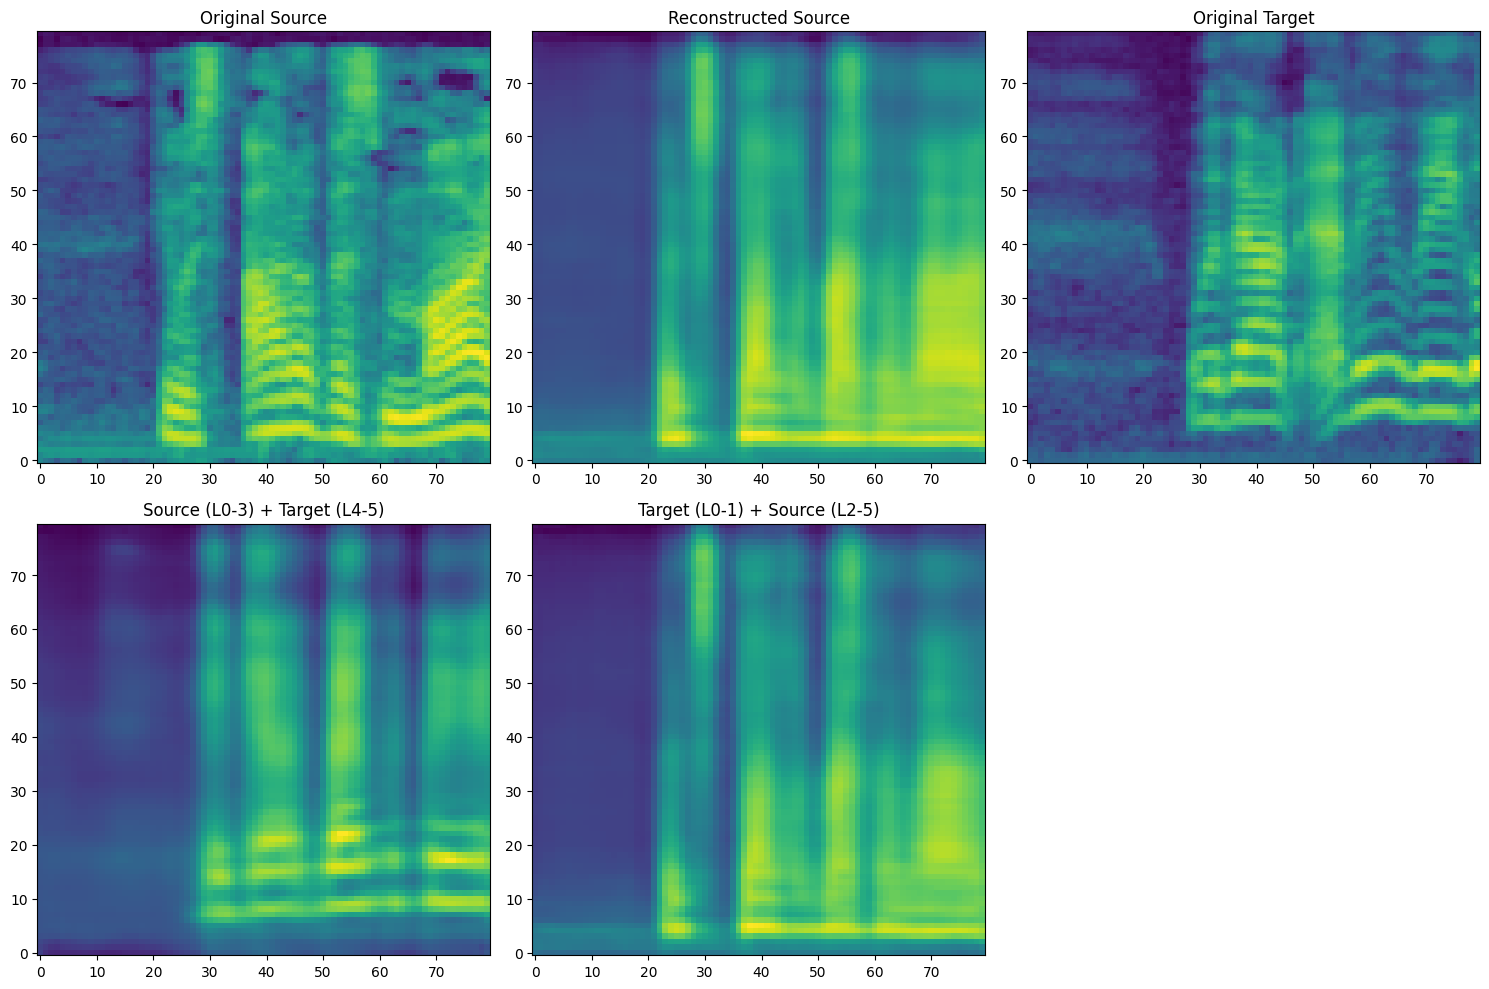

In [26]:
def perform_vc_test(model, source_batch, target_batch, device):
    model.eval()
    with torch.no_grad():
        # استخراج لایه‌های نهفته برای منبع و هدف
        _, levels_source = model(source_batch[:1].to(device))
        _, levels_target = model(target_batch[:1].to(device))
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # گرید را به 2x3 تغییر دادیم تا خانه خالی نماند
        
        # 1. داده‌های اصلی
        axes[0, 0].imshow(source_batch[0, 0].cpu(), origin='lower', aspect='auto')
        axes[0, 0].set_title("Original Source")
        
        axes[0, 2].imshow(target_batch[0, 0].cpu(), origin='lower', aspect='auto')
        axes[0, 2].set_title("Original Target")
        
        # 2. بازسازی منبع
        recon_s, _ = model(source_batch[:1].to(device))
        axes[0, 1].imshow(recon_s[0, 0].detach().cpu(), origin='lower', aspect='auto')
        axes[0, 1].set_title("Reconstructed Source")
        
        # 3. تست تعویض لایه‌های بالا (هویت گوینده / اطلاعات فرکانسی بالا)
        mixed_levels_high = levels_source[:4] + levels_target[4:]
        z_mixed_high = torch.cat(mixed_levels_high, dim=1)
        vc_high = model.decoder(z_mixed_high)
        axes[1, 0].imshow(vc_high[0, 0].detach().cpu(), origin='lower', aspect='auto')
        axes[1, 0].set_title("Source (L0-3) + Target (L4-5)")

        # 4. تست تعویض لایه‌های پایین (محتوا / گام کلی)
        mixed_levels_low = levels_target[:2] + levels_source[2:]
        z_mixed_low = torch.cat(mixed_levels_low, dim=1)
        vc_low = model.decoder(z_mixed_low)
        axes[1, 1].imshow(vc_low[0, 0].detach().cpu(), origin='lower', aspect='auto')
        axes[1, 1].set_title("Target (L0-1) + Source (L2-5)")

        # حذف پلات خالی آخر در ردیف دوم
        axes[1, 2].axis('off')

        plt.tight_layout()
        plt.show()

perform_vc_test(model, batch_a, batch_b, device)


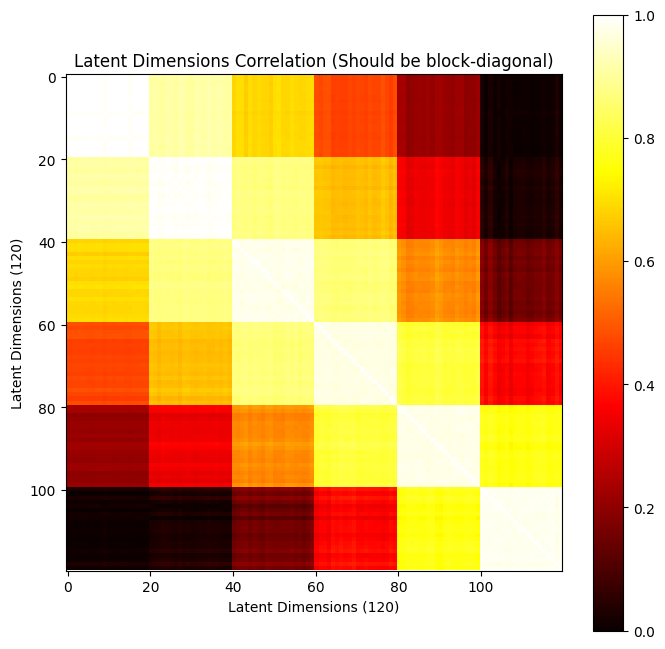

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# تعریف توابع مورد نیاز که در اسکریپت آموزش بودند
# ==========================================================
def covariance(x):
    x = x - x.mean(dim=0, keepdim=True)
    return (x.T @ x) / (x.size(0) - 1 + 1e-6)

def correlation(x):
    cov = covariance(x)
    std = torch.sqrt(torch.diag(cov) + 1e-6)
    return cov / (std[:, None] * std[None, :] + 1e-6)

# ==========================================================
# تست آنالیز استقلال (Heatmap)
# ==========================================================
def plot_latent_correlation(model, loader, device):
    model.eval()
    all_z = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            z, _ = model.encoder(batch.to(device))
            all_z.append(z)
            if i > 20:  # حدود ۶۰۰ نمونه برای تخمین همبستگی کافی است
                break
    
    all_z = torch.cat(all_z, dim=0)
    corr = correlation(all_z).cpu().numpy()
    
    plt.figure(figsize=(8, 8))
    # استفاده از قدر مطلق همبستگی برای وضوح بیشتر
    plt.imshow(np.abs(corr), cmap='hot', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar()
    plt.title("Latent Dimensions Correlation (Should be block-diagonal)")
    plt.xlabel("Latent Dimensions (120)")
    plt.ylabel("Latent Dimensions (120)")
    plt.show()

# اجرای تست
plot_latent_correlation(model, test_loader, device)


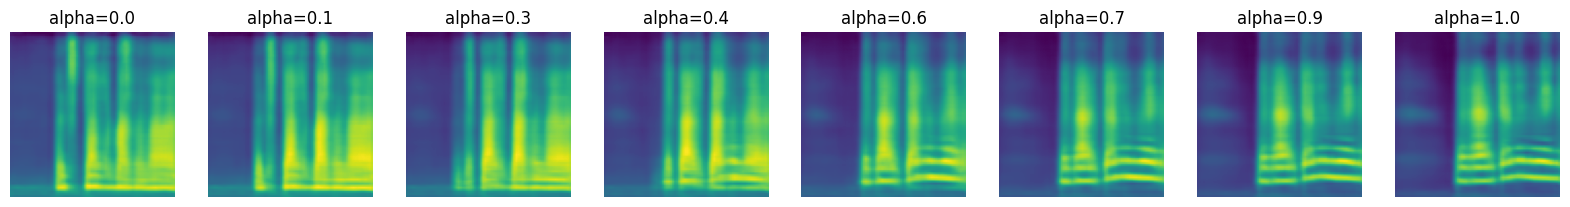

In [28]:
import numpy as np
def plot_interpolation(model, source_batch, target_batch, device):
    model.eval()
    with torch.no_grad():
        z_source, _ = model.encoder(source_batch[:1].to(device))
        z_target, _ = model.encoder(target_batch[:1].to(device))
        
        plt.figure(figsize=(20, 4))
        for i, alpha in enumerate(np.linspace(0, 1, 8)):
            z_interp = (1 - alpha) * z_source + alpha * z_target
            recon = model.decoder(z_interp)
            plt.subplot(1, 8, i+1)
            plt.imshow(recon[0,0].cpu(), origin='lower')
            plt.title(f"alpha={alpha:.1f}")
            plt.axis('off')
        plt.show()

plot_interpolation(model, batch_a, batch_b, device)


In [ ]:
#  تست نفوذ ویژگی (Feature Penetration Test)

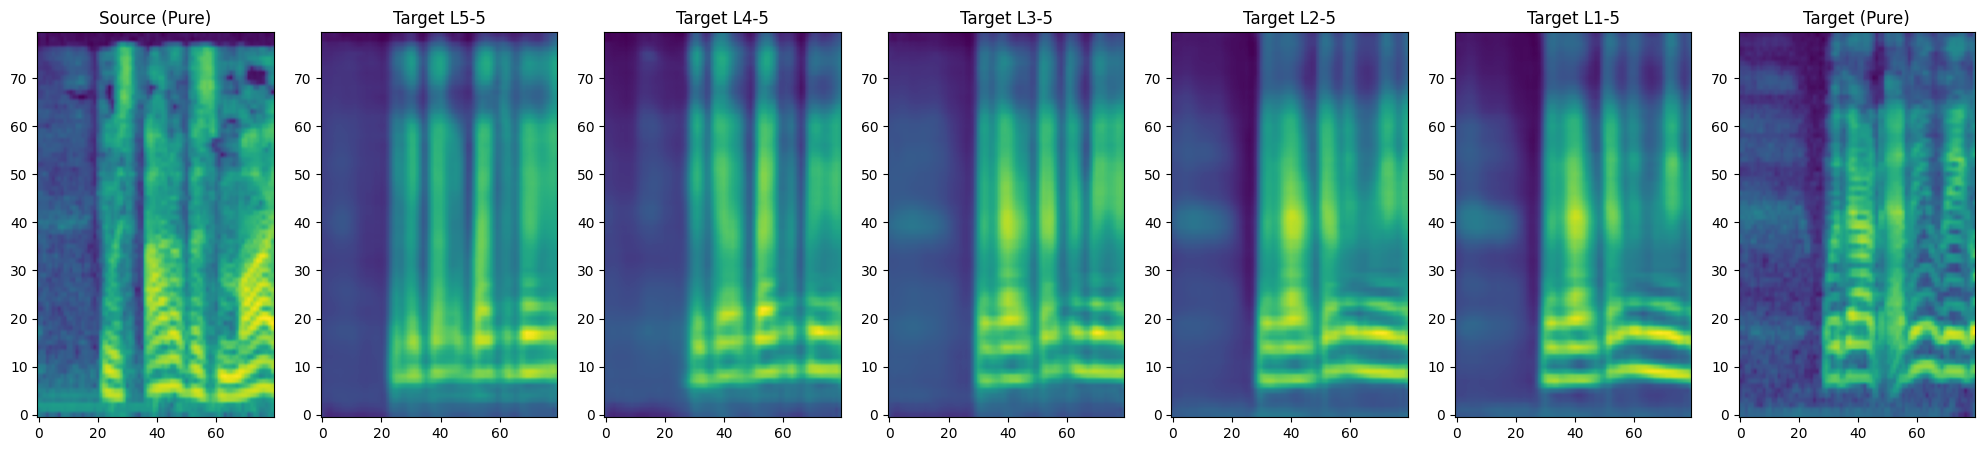

In [29]:
def feature_penetration_test(model, source_batch, target_batch, device):
    model.eval()
    with torch.no_grad():
        _, levels_s = model(source_batch[:1].to(device))
        _, levels_t = model(target_batch[:1].to(device))
        
        fig, axes = plt.subplots(1, 7, figsize=(25, 5))
        
        # نمایش منبع اصلی
        axes[0].imshow(source_batch[0,0].cpu(), origin='lower', aspect='auto')
        axes[0].set_title("Source (Pure)")
        
        # انتقال تجمعی لایه‌ها از Target به Source
        # لایه 5 بالاترین لایه (Speaker) و لایه 0 پایین‌ترین (Content/Pitch)
        for i in range(1, 6):
            # در هر مرحله یک لایه بیشتر از Target برمی‌داریم (از بالا به پایین)
            # مثلاً مرحله 1: فقط لایه 5 از Target. مرحله 2: لایه 4 و 5 از Target و ...
            mixed = levels_s[:6-i] + levels_t[6-i:]
            z_mixed = torch.cat(mixed, dim=1)
            vc_out = model.decoder(z_mixed)
            
            axes[i].imshow(vc_out[0,0].detach().cpu(), origin='lower', aspect='auto')
            axes[i].set_title(f"Target L{6-i}-5")
            
        # نمایش هدف اصلی
        axes[6].imshow(target_batch[0,0].cpu(), origin='lower', aspect='auto')
        axes[6].set_title("Target (Pure)")
        plt.show()

feature_penetration_test(model, batch_a, batch_b, device)


In [ ]:
# ۲. تست پیمایش لایه‌ای (Layer Traversal)

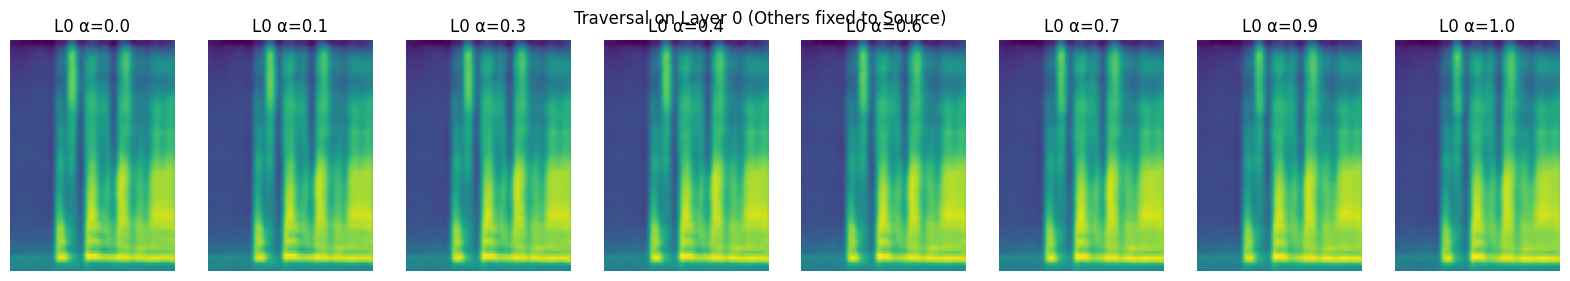

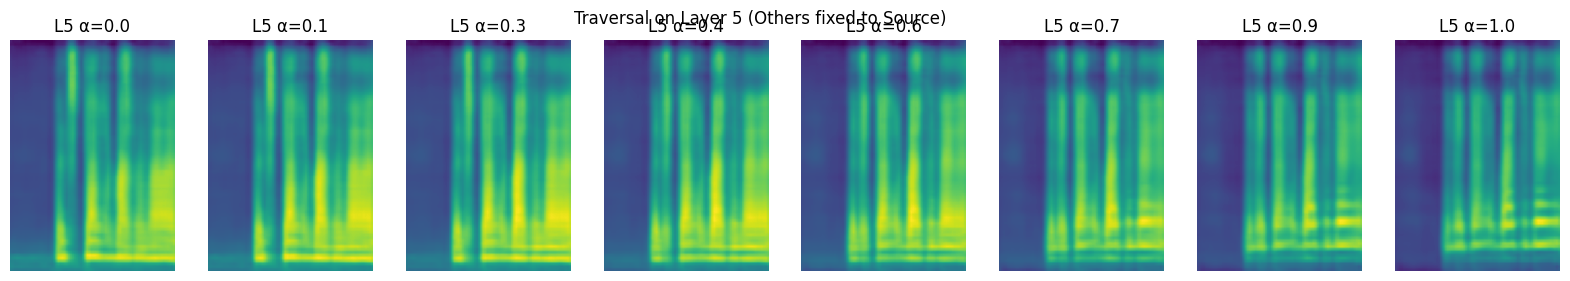

In [30]:
def layer_traversal_analysis(model, source_batch, target_batch, layer_idx, device):
    model.eval()
    with torch.no_grad():
        _, levels_s = model(source_batch[:1].to(device))
        _, levels_t = model(target_batch[:1].to(device))
        
        plt.figure(figsize=(20, 3))
        for i, alpha in enumerate(np.linspace(0, 1, 8)):
            # فقط لایه layer_idx را درون‌یابی کن، بقیه ثابت از Source
            current_levels = [l for l in levels_s]
            current_levels[layer_idx] = (1-alpha)*levels_s[layer_idx] + alpha*levels_t[layer_idx]
            
            z_interp = torch.cat(current_levels, dim=1)
            recon = model.decoder(z_interp)
            plt.subplot(1, 8, i+1)
            plt.imshow(recon[0,0].cpu(), origin='lower', aspect='auto')
            plt.title(f"L{layer_idx} α={alpha:.1f}")
            plt.axis('off')
        plt.suptitle(f"Traversal on Layer {layer_idx} (Others fixed to Source)")
        plt.show()

# پیشنهاد: این را برای لایه 0 (Content) و لایه 5 (Speaker) اجرا کن
layer_traversal_analysis(model, batch_a, batch_b, 0, device)
layer_traversal_analysis(model, batch_a, batch_b, 5, device)
